In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.dates as mdates
import matplotlib.colors as colors
import shapefile
from pyproj import CRS, Transformer
from scipy import signal
from scipy.fft import fft, fftfreq, ifft, next_fast_len
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from matplotlib_scalebar.scalebar import ScaleBar
import datetime
from matplotlib.lines import Line2D

In [2]:
roots = "C:/Users/simcosta/Documents/doc/Campo_2023/Campo_2023/Processados/"
file_names = ['ADCP1_UVSSC_REV.pkl', 'ADCP1_depth_REV.pkl', 'ADCP1_time_REV.pkl',
             'ADCP2_UVSSC_REV.pkl', 'ADCP2_depth_REV.pkl', 'ADCP2_time_REV.pkl',
            'ADCP3_UVSSC_REV.pkl', 'ADCP3_depth_REV.pkl', 'ADCP3_time_REV.pkl',
             'ADCP4_UVSSC_REV.pkl', 'ADCP4_depth_REV.pkl', 'ADCP4_time_REV.pkl']

# Dicionário para armazenar os dados já processados de velocidadee outros
data = {}

# Loop através dos nomes dos arquivos e carrega os dados usando pickle
for file_name in file_names:
    with open(roots+file_name, 'rb') as file:
        data[file_name.replace('.pkl', '')] = pickle.load(file)

In [3]:
M = np.sqrt(data['ADCP1_UVSSC_REV'][0]**2+data['ADCP1_UVSSC_REV'][1]**2)
UV_dir = np.arctan2(data['ADCP1_UVSSC_REV'][0]/M, data['ADCP1_UVSSC_REV'][1]/M) 
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360   

U1_spin = np.zeros((len(M), len(data['ADCP1_UVSSC_REV'][0][0,:])))
V1_spin = np.zeros((len(M), len(data['ADCP1_UVSSC_REV'][0][0,:])))

for i in range(len(data['ADCP1_UVSSC_REV'][0][0,:])):
    for j in range(len(M)):
        if (M[j,i] != 0):
            rot_ang = (UV_dir_degrees[j,i]+16-74.23)%360        
            V1_spin[j,i] = M[j,i]*np.cos(np.radians(rot_ang))
            U1_spin[j,i] = M[j,i]*np.sin(np.radians(rot_ang))



M = np.sqrt(data['ADCP2_UVSSC_REV'][0]**2+data['ADCP2_UVSSC_REV'][1]**2)
UV_dir = np.arctan2(data['ADCP2_UVSSC_REV'][0]/M, data['ADCP2_UVSSC_REV'][1]/M) 
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360   

U2_spin = np.zeros((len(M), len(data['ADCP2_UVSSC_REV'][0][0,:])))
V2_spin = np.zeros((len(M), len(data['ADCP2_UVSSC_REV'][0][0,:])))

for i in range(len(data['ADCP2_UVSSC_REV'][0][0,:])):
    for j in range(len(M)):
        if (M[j,i] != 0):
            rot_ang = (UV_dir_degrees[j,i]+16-64.93)%360        
            V2_spin[j,i] = M[j,i]*np.cos(np.radians(rot_ang))
            U2_spin[j,i] = M[j,i]*np.sin(np.radians(rot_ang))



M = np.sqrt(data['ADCP3_UVSSC_REV'][0]**2+data['ADCP3_UVSSC_REV'][1]**2)
UV_dir = np.arctan2(data['ADCP3_UVSSC_REV'][0]/M, data['ADCP3_UVSSC_REV'][1]/M) 
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360   

U3_spin = np.zeros((len(M), len(data['ADCP3_UVSSC_REV'][0][0,:])))
V3_spin = np.zeros((len(M), len(data['ADCP3_UVSSC_REV'][0][0,:])))

for i in range(len(data['ADCP3_UVSSC_REV'][0][0,:])):
    for j in range(len(M)):
        if (M[j,i] != 0):
            rot_ang = (UV_dir_degrees[j,i]+16-47.97)%360        
            V3_spin[j,i] = M[j,i]*np.cos(np.radians(rot_ang))
            U3_spin[j,i] = M[j,i]*np.sin(np.radians(rot_ang))



M = np.sqrt(data['ADCP4_UVSSC_REV'][0]**2+data['ADCP4_UVSSC_REV'][1]**2)
UV_dir = np.arctan2(data['ADCP4_UVSSC_REV'][0]/M, data['ADCP4_UVSSC_REV'][1]/M) 
UV_dir_degrees = np.rad2deg(UV_dir)
UV_dir_degrees[UV_dir_degrees < 0] += 360   

U4_spin = np.zeros((len(M), len(data['ADCP4_UVSSC_REV'][0][0,:])))
V4_spin = np.zeros((len(M), len(data['ADCP4_UVSSC_REV'][0][0,:])))

for i in range(len(data['ADCP4_UVSSC_REV'][0][0,:])):
    for j in range(len(M)):
        if (M[j,i] != 0):
            rot_ang = (UV_dir_degrees[j,i]+16-40.13)%360        
            V4_spin[j,i] = M[j,i]*np.cos(np.radians(rot_ang))
            U4_spin[j,i] = M[j,i]*np.sin(np.radians(rot_ang))

C:\Users\simcosta\AppData\Local\Temp\ipykernel_8760\2109738841.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data['ADCP1_UVSSC_REV'][1],data['ADCP1_UVSSC_REV'][0],c = 'r',cmap=plt.cm.jet, s = 0.5, label = 'declinação')
C:\Users\simcosta\AppData\Local\Temp\ipykernel_8760\2109738841.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(V1_spin,U1_spin,c = 'b',cmap=plt.cm.jet, s = 0.5, label = 'Com rotacao')


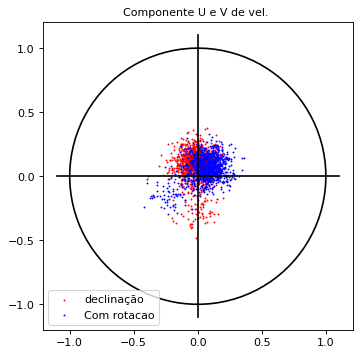

In [4]:
#Comparando os dados de vel. brutos com os dados rotacionados. 
fig, ax = plt.subplots(figsize=(5,5), dpi = 80)
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_y = np.cos(n)
ax.plot(circ_x, circ_y,'k')
ax.plot([0,0], [-1.1, 1.1], 'k')
ax.plot([-1.1, 1.1], [0, 0], 'k')
ax.axis('equal')
M = np.sqrt(V4_spin**2+U4_spin**2)
plt.title("Componente U e V de vel. ", fontsize=10)
ax.scatter(data['ADCP1_UVSSC_REV'][1],data['ADCP1_UVSSC_REV'][0],c = 'r',cmap=plt.cm.jet, s = 0.5, label = 'declinação')
ax.scatter(V1_spin,U1_spin,c = 'b',cmap=plt.cm.jet, s = 0.5, label = 'Com rotacao')
ax.legend()

In [5]:
P1_utm_E_init = 396102.197559
P1_utm_N_init = 6439967.08943

P2_utm_E_init = 395259.915163
P2_utm_N_init = 6439348.88736

P3_utm_E_init = 393947.507994
P3_utm_N_init = 6438615.82996

P4_utm_E_init = 393106.974459
P4_utm_N_init = 6437854.43456

# -------------FUNDO-------------
#1
hand = True
P1_utm_E_traj_fundo = []
P1_utm_N_traj_fundo = []

for i in range(len(data['ADCP1_time_REV'])):
    if hand:
        dist_E = P1_utm_E_init + (V1_spin[i, 0])*600
        dist_N = P1_utm_N_init + (U1_spin[i, 0])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V1_spin[i, 0])*600
        dist_N = dist_N + (U1_spin[i, 0])*600
    P1_utm_E_traj_fundo.append(dist_E)
    P1_utm_N_traj_fundo.append(dist_N)


#2
hand = True
P2_utm_E_traj_fundo = []
P2_utm_N_traj_fundo = []

for i in range(len(data['ADCP2_time_REV'])):
    if hand:
        dist_E = P2_utm_E_init + (V2_spin[i, 0])*600
        dist_N = P2_utm_N_init + (U2_spin[i, 0])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V2_spin[i, 0])*600
        dist_N = dist_N + (U2_spin[i, 0])*600
    P2_utm_E_traj_fundo.append(dist_E)
    P2_utm_N_traj_fundo.append(dist_N)


#3
hand = True
P3_utm_E_traj_fundo = []
P3_utm_N_traj_fundo = []

for i in range(len(data['ADCP3_time_REV'])):
    if hand:
        dist_E = P3_utm_E_init + (V3_spin[i, 0])*600
        dist_N = P3_utm_N_init + (U3_spin[i, 0])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V3_spin[i, 0])*600
        dist_N = dist_N + (U3_spin[i, 0])*600
    P3_utm_E_traj_fundo.append(dist_E)
    P3_utm_N_traj_fundo.append(dist_N)


#4
hand = True
P4_utm_E_traj_fundo = []
P4_utm_N_traj_fundo = []

for i in range(len(data['ADCP4_time_REV'])):
    if hand:
        dist_E = P4_utm_E_init + (V4_spin[i, 0])*600
        dist_N = P4_utm_N_init + (U4_spin[i, 0])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V4_spin[i, 0])*600
        dist_N = dist_N + (U4_spin[i, 0])*600
    P4_utm_E_traj_fundo.append(dist_E)
    P4_utm_N_traj_fundo.append(dist_N)


# -------------TOPO-------------
#1
hand = True
P1_utm_E_traj_topo = []
P1_utm_N_traj_topo = []

for i in range(len(data['ADCP1_time_REV'])):
    if hand:
        dist_E = P1_utm_E_init + (V1_spin[i, -1])*600
        dist_N = P1_utm_N_init + (U1_spin[i, -1])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V1_spin[i, -1])*600
        dist_N = dist_N + (U1_spin[i, -1])*600
    P1_utm_E_traj_topo.append(dist_E)
    P1_utm_N_traj_topo.append(dist_N)


#2
hand = True
P2_utm_E_traj_topo = []
P2_utm_N_traj_topo = []

for i in range(len(data['ADCP2_time_REV'])):
    if hand:
        dist_E = P2_utm_E_init + (V2_spin[i, -2])*600
        dist_N = P2_utm_N_init + (U2_spin[i, -2])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V2_spin[i, -2])*600
        dist_N = dist_N + (U2_spin[i, -2])*600
    P2_utm_E_traj_topo.append(dist_E)
    P2_utm_N_traj_topo.append(dist_N)

#3
hand = True
P3_utm_E_traj_topo = []
P3_utm_N_traj_topo = []

for i in range(len(data['ADCP3_time_REV'])):
    if hand:
        dist_E = P3_utm_E_init + (V3_spin[i, -1])*600
        dist_N = P3_utm_N_init + (U3_spin[i, -1])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V3_spin[i, -1])*600
        dist_N = dist_N + (U3_spin[i, -1])*600
    P3_utm_E_traj_topo.append(dist_E)
    P3_utm_N_traj_topo.append(dist_N)


#4
hand = True
P4_utm_E_traj_topo = []
P4_utm_N_traj_topo = []

for i in range(len(data['ADCP4_time_REV'])):
    if hand:
        dist_E = P4_utm_E_init + (V4_spin[i, -1])*600
        dist_N = P4_utm_N_init + (U4_spin[i, -1])*600
        hand = False
    if not hand:
        dist_E = dist_E + (V4_spin[i, -1])*600
        dist_N = dist_N + (U4_spin[i, -1])*600
    P4_utm_E_traj_topo.append(dist_E)
    P4_utm_N_traj_topo.append(dist_N)

In [6]:
fp = "D:/ArcGIS/Cartas_Raster/Rio Grande/2110geotiff/2110geotiff.tif"

img = rasterio.open(fp)

# Definir a projeção de destino para UTM 22S
dst_crs = 'EPSG:32722'

# Calcular a transformação necessária para reprojetar a imagem
transform, width, height = calculate_default_transform(
    img.crs, dst_crs, img.width, img.height, *img.bounds)

# Configurar metadados para a imagem reprojetada
kwargs = img.meta.copy()
kwargs.update({
    'crs': dst_crs,
    'transform': transform,
    'width': width,
    'height': height
})

# Criar um array para a imagem reprojetada
reprojected_img = np.zeros((img.count, height, width), dtype=img.dtypes[0])

# Reprojetar cada banda
for i in range(1, img.count + 1):
    reproject(
        source=rasterio.band(img, i),
        destination=reprojected_img[i - 1],
        src_transform=img.transform,
        src_crs=img.crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest)

# Empilhar as bandas reprojetadas em uma imagem RGB
rgb_img_reprojected = np.stack([reprojected_img[0], reprojected_img[1], reprojected_img[2]], axis=-1)

In [7]:
fn = 'C:/Users/simcosta/Documents/doc/Campo_2023/Campo_2023/dados_brutos/SIMCOSTA_RS-5_MET_2023-11-28_2023-11-29.csv'

dataw = np.genfromtxt(fn, delimiter=',',skip_header=1)

# Convertendo a data e hora para datetime.datetime
dt = []
dt_stamp = []
for row in dataw[:]:
    dt.append(datetime.datetime(int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4]), int(row[5])))
    dt_stamp.append(datetime.datetime.timestamp(datetime.datetime(int(row[0]), int(row[1]), int(row[2]), int(row[3]), int(row[4]), int(row[5]))))

wind_pa = dataw[6:56, 6]
wind_mag = dataw[6:56, 7]
wind_dir = dataw[6:56, 8]


wU_spin = np.zeros(len(wind_mag))
wV_spin = np.zeros(len(wind_mag))



for j in range(len(wind_mag)):
    if (wind_mag[j] != 0):
        rot_ang = (wind_dir[j]+180)%360
        wU_spin[j] = wind_mag[j]*np.cos(np.radians(rot_ang))
        wV_spin[j] = wind_mag[j]*np.sin(np.radians(rot_ang))

(6432000.0, 6443000.0)

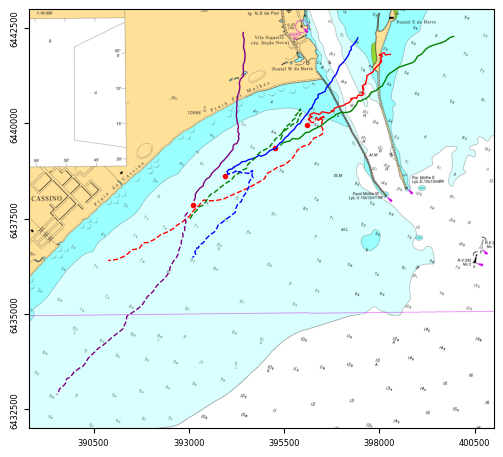

In [8]:
# Configurar a figura e o eixo
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# Exibir a imagem reprojetada com a extensão correta
ax.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])



ax.plot(P1_utm_E_init, P1_utm_N_init, '.', color ='r')
ax.plot(P2_utm_E_init, P2_utm_N_init, '.', color ='r')
ax.plot(P3_utm_E_init, P3_utm_N_init, '.', color ='r')
ax.plot(P4_utm_E_init, P4_utm_N_init, '.', color ='r')


#fundo
ax.plot(P1_utm_E_traj_fundo, P1_utm_N_traj_fundo, lw = 1, color ='r')
ax.plot(P2_utm_E_traj_fundo, P2_utm_N_traj_fundo, lw = 1, color ='g')
ax.plot(P3_utm_E_traj_fundo, P3_utm_N_traj_fundo, lw = 1, color ='b')
ax.plot(P4_utm_E_traj_fundo, P4_utm_N_traj_fundo, lw = 1, color ='purple')

#topo
ax.plot(P1_utm_E_traj_topo, P1_utm_N_traj_topo, '--', lw = 1, color ='r')
ax.plot(P2_utm_E_traj_topo, P2_utm_N_traj_topo, '--', lw = 1, color ='g')
ax.plot(P3_utm_E_traj_topo, P3_utm_N_traj_topo, '--', lw = 1, color ='b')
ax.plot(P4_utm_E_traj_topo, P4_utm_N_traj_topo, '--', lw = 1, color ='purple')

#ax.axis('equal')
ax.set_yticks([6432500, 6435000, 6437500, 6440000, 6442500], [6432500, 6435000, 6437500, 6440000, 6442500], verticalalignment = 'center', fontsize = 6, rotation=90)
ax.set_xticks([388000, 390500, 393000, 395500, 398000, 400500], [388000, 390500, 393000, 395500, 398000, 400500], fontsize = 6)

ax.set_xlim([388800, 401000]) 
ax.set_ylim([6432000, 6443000])

Text(0.02, 0.92, '(c)')

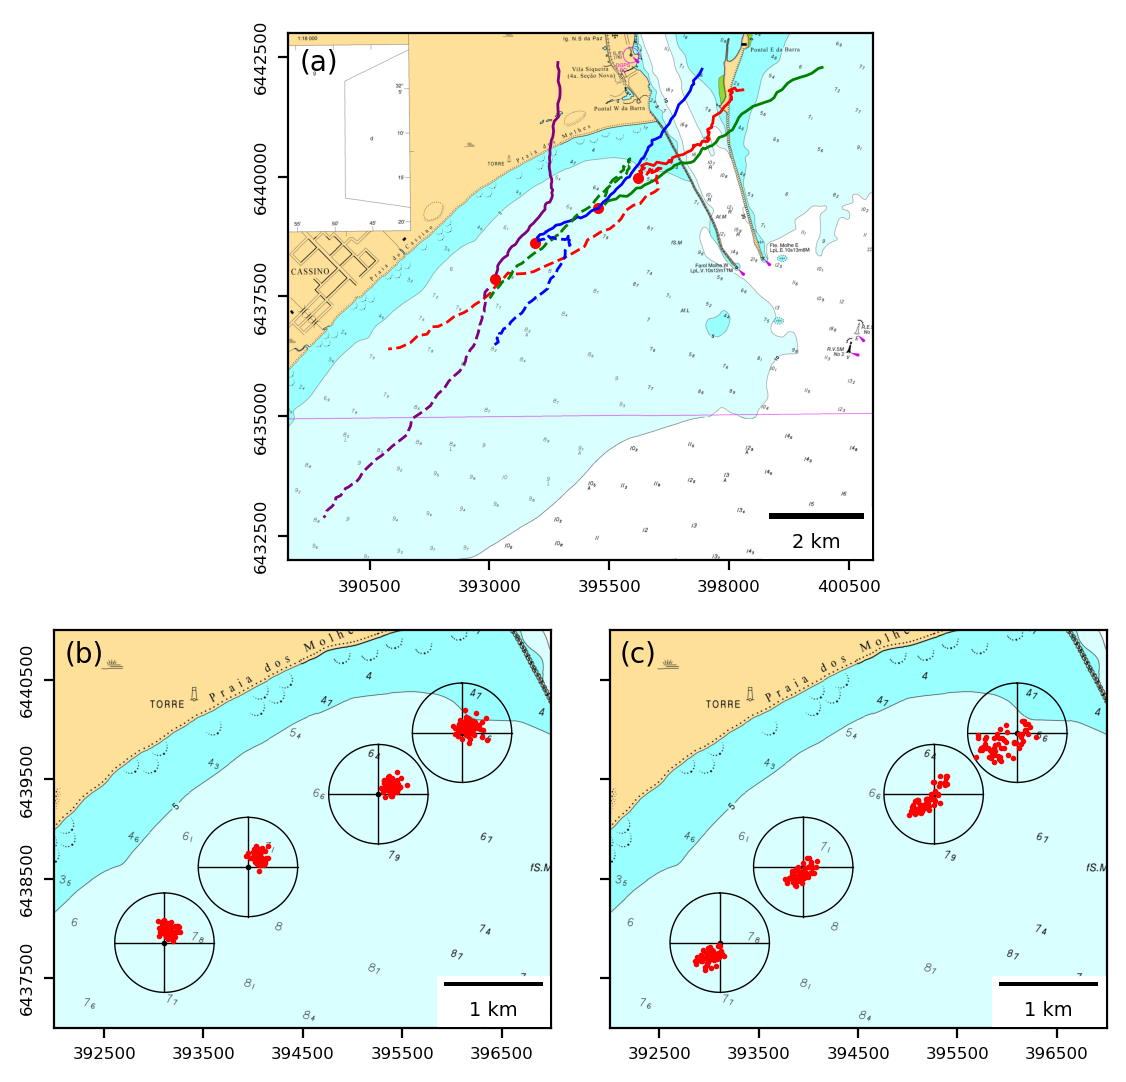

In [9]:
escala = 1000

fig = plt.figure(figsize=(5.845, 5.845), dpi=200)

width1 = 388800 - 401000
height1 = 6432000 - 6443000
aspect_ratio1 = height1 / width1

width2 = 392000 - 397000
height2 = 6437000 - 6441000
aspect_ratio2 = height2 / width2

spacing_vertical = 0.01
spacing_horizontal = 0.05
ax2 = fig.add_axes([0.1, 0.1, 0.45 - spacing_horizontal/2, 0.45 * aspect_ratio2])
ax3 = fig.add_axes([0.55 + spacing_horizontal/2, 0.1, 0.45 - spacing_horizontal/2, 0.45 * aspect_ratio2])
ax1_width = 0.5
ax1_height = ax1_width * aspect_ratio1
ax1_left = (ax2.get_position().x1 + ax3.get_position().x0 - ax1_width) / 2
ax1_bottom = 0.5 + spacing_vertical

# Adicionar ax1 centralizado
ax1 = fig.add_axes([ax1_left, ax1_bottom, ax1_width, ax1_height])

# Exibir a imagem reprojetada com a extensão correta
ax1.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])



ax1.plot(P1_utm_E_init, P1_utm_N_init, '.', color ='r')
ax1.plot(P2_utm_E_init, P2_utm_N_init, '.', color ='r')
ax1.plot(P3_utm_E_init, P3_utm_N_init, '.', color ='r')
ax1.plot(P4_utm_E_init, P4_utm_N_init, '.', color ='r')


#fundo
ax1.plot(P1_utm_E_traj_fundo, P1_utm_N_traj_fundo, lw = 1, color ='r')
ax1.plot(P2_utm_E_traj_fundo, P2_utm_N_traj_fundo, lw = 1, color ='g')
ax1.plot(P3_utm_E_traj_fundo, P3_utm_N_traj_fundo, lw = 1, color ='b')
ax1.plot(P4_utm_E_traj_fundo, P4_utm_N_traj_fundo, lw = 1, color ='purple')

#topo
ax1.plot(P1_utm_E_traj_topo, P1_utm_N_traj_topo, '--', lw = 1, color ='r')
ax1.plot(P2_utm_E_traj_topo, P2_utm_N_traj_topo, '--', lw = 1, color ='g')
ax1.plot(P3_utm_E_traj_topo, P3_utm_N_traj_topo, '--', lw = 1, color ='b')
ax1.plot(P4_utm_E_traj_topo, P4_utm_N_traj_topo, '--', lw = 1, color ='purple')

#ax.axis('equal')
ax1.set_yticks([6432500, 6435000, 6437500, 6440000, 6442500], [6432500, 6435000, 6437500, 6440000, 6442500], verticalalignment = 'center', fontsize = 6, rotation=90)
ax1.set_xticks([388000, 390500, 393000, 395500, 398000, 400500], [388000, 390500, 393000, 395500, 398000, 400500], fontsize = 6)

ax1.set_xlim([388800, 401000]) 
ax1.set_ylim([6432000, 6443000])
scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax1.add_artist(scalebar)



ax2.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])
U1_img = U1_spin[:, 0]*escala+P1_utm_N_init
V1_img = V1_spin[:, 0]*escala+P1_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P1_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P1_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P1_utm_E_init, P1_utm_E_init], [P1_utm_N_init-500, P1_utm_N_init+500],'k', lw = .5)
ax2.plot([P1_utm_E_init-500, P1_utm_E_init+500], [P1_utm_N_init, P1_utm_N_init],'k', lw = .5)
ax2.plot(V1_img, U1_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P1_utm_E_init, P1_utm_N_init, color ='k', s= 1)

U2_img = U2_spin[:, 0]*escala+P2_utm_N_init
V2_img = V2_spin[:, 0]*escala+P2_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P2_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P2_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P2_utm_E_init, P2_utm_E_init], [P2_utm_N_init-500, P2_utm_N_init+500],'k', lw = .5)
ax2.plot([P2_utm_E_init-500, P2_utm_E_init+500], [P2_utm_N_init, P2_utm_N_init],'k', lw = .5)
ax2.plot(V2_img, U2_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P2_utm_E_init, P2_utm_N_init, color ='k', s= 1)

U3_img = U3_spin[:, 0]*escala+P3_utm_N_init
V3_img = V3_spin[:, 0]*escala+P3_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P3_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P3_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P3_utm_E_init, P3_utm_E_init], [P3_utm_N_init-500, P3_utm_N_init+500],'k', lw = .5)
ax2.plot([P3_utm_E_init-500, P3_utm_E_init+500], [P3_utm_N_init, P3_utm_N_init],'k', lw = .5)
ax2.plot(V3_img, U3_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P3_utm_E_init, P3_utm_N_init, color ='k', s= 1)

U4_img = U4_spin[:, 0]*escala+P4_utm_N_init
V4_img = V4_spin[:, 0]*escala+P4_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P4_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P4_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P4_utm_E_init, P4_utm_E_init], [P4_utm_N_init-500, P4_utm_N_init+500],'k', lw = .5)
ax2.plot([P4_utm_E_init-500, P4_utm_E_init+500], [P4_utm_N_init, P4_utm_N_init],'k', lw = .5)
ax2.plot(V4_img, U4_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P4_utm_E_init, P4_utm_N_init, color ='k', s= 1)

ax2.set_xlim([392000, 397000]) 
ax2.set_ylim([6437000, 6441000])
ax2.set_xticks([392500, 393500, 394500, 395500, 396500], [392500, 393500, 394500, 395500, 396500], fontsize = 6)
ax2.set_yticks([6437500, 6438500, 6439500, 6440500], [6437500, 6438500, 6439500, 6440500], verticalalignment = 'center', fontsize = 6, rotation=90)

scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax2.add_artist(scalebar)


ax3.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])
U1_img = U1_spin[:, -1]*escala+P1_utm_N_init
V1_img = V1_spin[:, -1]*escala+P1_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P1_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P1_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P1_utm_E_init, P1_utm_E_init], [P1_utm_N_init-500, P1_utm_N_init+500],'k', lw = .5)
ax3.plot([P1_utm_E_init-500, P1_utm_E_init+500], [P1_utm_N_init, P1_utm_N_init],'k', lw = .5)
ax3.plot(V1_img, U1_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P1_utm_E_init, P1_utm_N_init, color ='k', s= 1)

U2_img = U2_spin[:, -2]*escala+P2_utm_N_init
V2_img = V2_spin[:, -2]*escala+P2_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P2_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P2_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P2_utm_E_init, P2_utm_E_init], [P2_utm_N_init-500, P2_utm_N_init+500],'k', lw = .5)
ax3.plot([P2_utm_E_init-500, P2_utm_E_init+500], [P2_utm_N_init, P2_utm_N_init],'k', lw = .5)
ax3.plot(V2_img, U2_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P2_utm_E_init, P2_utm_N_init, color ='k', s= 1)

U3_img = U3_spin[:, -1]*escala+P3_utm_N_init
V3_img = V3_spin[:, -1]*escala+P3_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P3_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P3_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P3_utm_E_init, P3_utm_E_init], [P3_utm_N_init-500, P3_utm_N_init+500],'k', lw = .5)
ax3.plot([P3_utm_E_init-500, P3_utm_E_init+500], [P3_utm_N_init, P3_utm_N_init],'k', lw = .5)
ax3.plot(V3_img, U3_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P3_utm_E_init, P3_utm_N_init, color ='k', s= 1)

U4_img = U4_spin[:, -1]*escala+P4_utm_N_init
V4_img = V4_spin[:, -1]*escala+P4_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P4_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P4_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P4_utm_E_init, P4_utm_E_init], [P4_utm_N_init-500, P4_utm_N_init+500],'k', lw = .5)
ax3.plot([P4_utm_E_init-500, P4_utm_E_init+500], [P4_utm_N_init, P4_utm_N_init],'k', lw = .5)
ax3.plot(V4_img, U4_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P4_utm_E_init, P4_utm_N_init, color ='k', s= 1)

ax3.set_xlim([392000, 397000]) 
ax3.set_ylim([6437000, 6441000])
ax3.set_xticks([392500, 393500, 394500, 395500, 396500], [392500, 393500, 394500, 395500, 396500], fontsize = 6)
ax3.set_yticks([6437500, 6438500, 6439500, 6440500], [], verticalalignment = 'center', fontsize = 6, rotation=90)

scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax3.add_artist(scalebar)


ax1.text(0.02, .93, '(a)', transform=ax1.transAxes, fontsize=10)
ax2.text(0.02, .92, '(b)', transform=ax2.transAxes, fontsize=10)
ax3.text(0.02, .92, '(c)', transform=ax3.transAxes, fontsize=10)


Text(0.18, 0.1, '0.5 m/s')

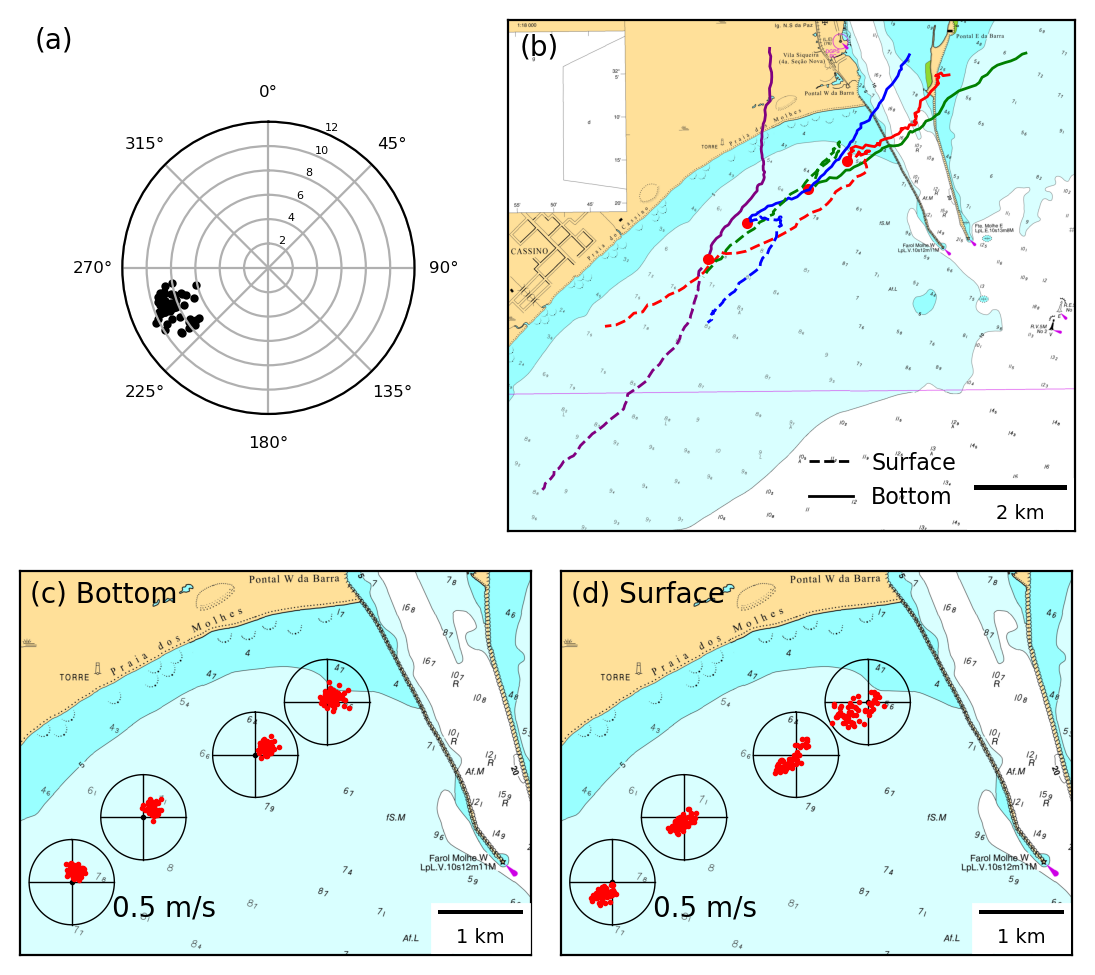

In [11]:
escala = 1000

fig = plt.figure(figsize=(5.845, 5.845), dpi=200)

width1 = 388800 - 401000
height1 = 6432000 - 6443000
aspect_ratio1 = height1 / width1

width2 = 392500 - 398500
height2 = 6437000 - 6441500
aspect_ratio2 = height2 / width2

spacing_vertical = 0.005
spacing_horizontal = 0.025
ax2 = fig.add_axes([0, 0.1, 0.45 - spacing_horizontal/2, 0.55 * aspect_ratio2])
ax3 = fig.add_axes([0.45 + spacing_horizontal/2, 0.1, 0.45 - spacing_horizontal/2, 0.55 * aspect_ratio2])
ax1_width = 0.485
ax1_height = ax1_width * aspect_ratio1
ax1_left = (ax2.get_position().x1 + ax3.get_position().x0 - ax1_width) / 2
ax1_bottom = 0.5 + spacing_vertical

# Adicionar ax1 centralizado
ax1 = fig.add_axes([0.405 + spacing_horizontal/2, ax1_bottom, ax1_width, ax1_height])
ax4 = fig.add_axes([0.075 + spacing_horizontal/2, ax1_bottom+0.1, 0.25, 0.25], polar = True)

# Exibir a imagem reprojetada com a extensão correta
ax1.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])



ax1.plot(P1_utm_E_init, P1_utm_N_init, '.', color ='r')
ax1.plot(P2_utm_E_init, P2_utm_N_init, '.', color ='r')
ax1.plot(P3_utm_E_init, P3_utm_N_init, '.', color ='r')
ax1.plot(P4_utm_E_init, P4_utm_N_init, '.', color ='r')


#fundo
ax1.plot(P1_utm_E_traj_fundo, P1_utm_N_traj_fundo, lw = 1, color ='r')
ax1.plot(P2_utm_E_traj_fundo, P2_utm_N_traj_fundo, lw = 1, color ='g')
ax1.plot(P3_utm_E_traj_fundo, P3_utm_N_traj_fundo, lw = 1, color ='b')
ax1.plot(P4_utm_E_traj_fundo, P4_utm_N_traj_fundo, lw = 1, color ='purple')

#topo
ax1.plot(P1_utm_E_traj_topo, P1_utm_N_traj_topo, '--', lw = 1, color ='r')
ax1.plot(P2_utm_E_traj_topo, P2_utm_N_traj_topo, '--', lw = 1, color ='g')
ax1.plot(P3_utm_E_traj_topo, P3_utm_N_traj_topo, '--', lw = 1, color ='b')
ax1.plot(P4_utm_E_traj_topo, P4_utm_N_traj_topo, '--', lw = 1, color ='purple')


ax1.set_yticks([], [], verticalalignment = 'center', fontsize = 7, rotation=90)
ax1.set_xticks([], [], fontsize = 7)

ax1.set_xlim([388800, 401000]) 
ax1.set_ylim([6432000, 6443000])
scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax1.add_artist(scalebar)



ax2.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])
U1_img = U1_spin[:, 0]*escala+P1_utm_N_init
V1_img = V1_spin[:, 0]*escala+P1_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P1_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P1_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P1_utm_E_init, P1_utm_E_init], [P1_utm_N_init-500, P1_utm_N_init+500],'k', lw = .5)
ax2.plot([P1_utm_E_init-500, P1_utm_E_init+500], [P1_utm_N_init, P1_utm_N_init],'k', lw = .5)
ax2.plot(V1_img, U1_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P1_utm_E_init, P1_utm_N_init, color ='k', s= 1)

U2_img = U2_spin[:, 0]*escala+P2_utm_N_init
V2_img = V2_spin[:, 0]*escala+P2_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P2_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P2_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P2_utm_E_init, P2_utm_E_init], [P2_utm_N_init-500, P2_utm_N_init+500],'k', lw = .5)
ax2.plot([P2_utm_E_init-500, P2_utm_E_init+500], [P2_utm_N_init, P2_utm_N_init],'k', lw = .5)
ax2.plot(V2_img, U2_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P2_utm_E_init, P2_utm_N_init, color ='k', s= 1)

U3_img = U3_spin[:, 0]*escala+P3_utm_N_init
V3_img = V3_spin[:, 0]*escala+P3_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P3_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P3_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P3_utm_E_init, P3_utm_E_init], [P3_utm_N_init-500, P3_utm_N_init+500],'k', lw = .5)
ax2.plot([P3_utm_E_init-500, P3_utm_E_init+500], [P3_utm_N_init, P3_utm_N_init],'k', lw = .5)
ax2.plot(V3_img, U3_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P3_utm_E_init, P3_utm_N_init, color ='k', s= 1)

U4_img = U4_spin[:, 0]*escala+P4_utm_N_init
V4_img = V4_spin[:, 0]*escala+P4_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P4_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P4_utm_N_init
ax2.plot(circ_x, circ_y,'k', lw = .5)
ax2.plot([P4_utm_E_init, P4_utm_E_init], [P4_utm_N_init-500, P4_utm_N_init+500],'k', lw = .5)
ax2.plot([P4_utm_E_init-500, P4_utm_E_init+500], [P4_utm_N_init, P4_utm_N_init],'k', lw = .5)
ax2.plot(V4_img, U4_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax2.scatter(P4_utm_E_init, P4_utm_N_init, color ='k', s= 1)

ax2.set_xlim([392500, 398500]) 
ax2.set_ylim([6437000, 6441500])
ax2.set_xticks([],  [], fontsize = 7)
ax2.set_yticks([], [], verticalalignment = 'center', fontsize = 7, rotation=90)

scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax2.add_artist(scalebar)


ax3.imshow(rgb_img_reprojected, extent=[transform[2], transform[2] + width * transform[0], transform[5] + height * transform[4], transform[5]])
U1_img = U1_spin[:, -1]*escala+P1_utm_N_init
V1_img = V1_spin[:, -1]*escala+P1_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P1_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P1_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P1_utm_E_init, P1_utm_E_init], [P1_utm_N_init-500, P1_utm_N_init+500],'k', lw = .5)
ax3.plot([P1_utm_E_init-500, P1_utm_E_init+500], [P1_utm_N_init, P1_utm_N_init],'k', lw = .5)
ax3.plot(V1_img, U1_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P1_utm_E_init, P1_utm_N_init, color ='k', s= 1)

U2_img = U2_spin[:, -2]*escala+P2_utm_N_init
V2_img = V2_spin[:, -2]*escala+P2_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P2_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P2_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P2_utm_E_init, P2_utm_E_init], [P2_utm_N_init-500, P2_utm_N_init+500],'k', lw = .5)
ax3.plot([P2_utm_E_init-500, P2_utm_E_init+500], [P2_utm_N_init, P2_utm_N_init],'k', lw = .5)
ax3.plot(V2_img, U2_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P2_utm_E_init, P2_utm_N_init, color ='k', s= 1)

U3_img = U3_spin[:, -1]*escala+P3_utm_N_init
V3_img = V3_spin[:, -1]*escala+P3_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P3_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P3_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P3_utm_E_init, P3_utm_E_init], [P3_utm_N_init-500, P3_utm_N_init+500],'k', lw = .5)
ax3.plot([P3_utm_E_init-500, P3_utm_E_init+500], [P3_utm_N_init, P3_utm_N_init],'k', lw = .5)
ax3.plot(V3_img, U3_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P3_utm_E_init, P3_utm_N_init, color ='k', s= 1)

U4_img = U4_spin[:, -1]*escala+P4_utm_N_init
V4_img = V4_spin[:, -1]*escala+P4_utm_E_init
n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_x = circ_x*500+P4_utm_E_init
circ_y = np.cos(n)
circ_y = circ_y*500+P4_utm_N_init
ax3.plot(circ_x, circ_y,'k', lw = .5)
ax3.plot([P4_utm_E_init, P4_utm_E_init], [P4_utm_N_init-500, P4_utm_N_init+500],'k', lw = .5)
ax3.plot([P4_utm_E_init-500, P4_utm_E_init+500], [P4_utm_N_init, P4_utm_N_init],'k', lw = .5)
ax3.plot(V4_img, U4_img, 'o', markersize=1, markerfacecolor='r', color ='r')
ax3.scatter(P4_utm_E_init, P4_utm_N_init, color ='k', s= 1)

ax3.set_xlim([392500, 398500]) 
ax3.set_ylim([6437000, 6441500])
ax3.set_xticks([], [], fontsize = 7)
ax3.set_yticks([], [], verticalalignment = 'center', fontsize = 6, rotation=90)

scalebar = ScaleBar(1, location='lower right', font_properties={"size": 7})
ax3.add_artist(scalebar)


speed = wind_mag
theta = np.deg2rad(wind_dir + 180)
sc = ax4.scatter(theta, speed, color = 'k', s=4)
ax4.set_theta_zero_location("N")
ax4.set_theta_direction(-1)
ax4.tick_params(axis='both', labelsize=6, pad = 0)
ax4.set_rgrids(ax4.get_yticks(), fontsize=4)


ax4.text(-0.3, 1.25, '(a)', transform=ax4.transAxes, fontsize=10)
ax2.text(0.02, .92, '(c) Bottom', transform=ax2.transAxes, fontsize=10)
ax1.text(0.02, .93, '(b)', transform=ax1.transAxes, fontsize=10)
ax3.text(0.02, .92, '(d) Surface', transform=ax3.transAxes, fontsize=10)


legend_lines = [
    Line2D([0], [0], color='k', lw=1, linestyle='--', label='Surface'),
    Line2D([0], [0], color='k', lw=1, linestyle='-', label='Bottom')
]

ax1.legend(
    handles=legend_lines,
    loc='lower right',
    bbox_to_anchor=(0.825, 0.005),
    fontsize=8,
    frameon=False
)


ax2.text(0.18, .1, '0.5 m/s', transform=ax2.transAxes, fontsize=10)
ax3.text(0.18, .1, '0.5 m/s', transform=ax3.transAxes, fontsize=10)


In [11]:
#
print('east fundo')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = P1_utm_E_init - P1_utm_E_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = P2_utm_E_init - P2_utm_E_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = P3_utm_E_init - P3_utm_E_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = P4_utm_E_init - P4_utm_E_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))


east fundo
-2.19
-4.68
-3.49
-1.32


In [12]:
#
print('east topo')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = P1_utm_E_init - P1_utm_E_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = P2_utm_E_init - P2_utm_E_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = P3_utm_E_init - P3_utm_E_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff =P4_utm_E_init - P4_utm_E_traj_topo[-1]
print(np.round(dist_diff/1000, 2))


east topo
5.22
2.26
0.85
3.57


In [13]:
#
print('north fundo')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = P1_utm_N_init - P1_utm_N_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = P2_utm_N_init - P2_utm_N_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = P3_utm_N_init - P3_utm_N_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = P4_utm_N_init - P4_utm_N_traj_fundo[-1]
print(np.round(dist_diff/1000, 2))


north fundo
-1.85
-2.93
-3.63
-4.53


In [14]:
#
print('north topo')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = P1_utm_N_init - P1_utm_N_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = P2_utm_N_init - P2_utm_N_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = P3_utm_N_init - P3_utm_N_traj_topo[-1]
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = P4_utm_N_init - P4_utm_N_traj_topo[-1]
print(np.round(dist_diff/1000, 2))


north topo
3.57
1.89
2.14
4.97


In [15]:
#
print('total / sec')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = np.sqrt(np.abs(P1_utm_E_init - P1_utm_E_traj_fundo[-1])**2 + np.abs(P1_utm_N_init - P1_utm_N_traj_fundo[-1])**2)
print(np.round((dist_diff / (time_diff.total_seconds())), 3))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = np.sqrt(np.abs(P2_utm_E_init - P2_utm_E_traj_fundo[-1])**2 + np.abs(P2_utm_N_init - P2_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff / (time_diff.total_seconds()), 3))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = np.sqrt(np.abs(P3_utm_E_init - P3_utm_E_traj_fundo[-1])**2 + np.abs(P3_utm_N_init - P3_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff / (time_diff.total_seconds()), 3))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = np.sqrt(np.abs(P4_utm_E_init - P4_utm_E_traj_fundo[-1])**2 + np.abs(P4_utm_N_init - P4_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff / (time_diff.total_seconds()), 3))

total / sec
0.081
0.159
0.153
0.138


In [16]:
#
dist_diff = np.abs(P1_utm_N_init - P1_utm_N_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P2_utm_N_init - P2_utm_N_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P3_utm_N_init - P3_utm_N_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P4_utm_N_init - P4_utm_N_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))


1.8
2.9
3.6
4.5


In [17]:
#
dist_diff = np.abs(P1_utm_E_init - P1_utm_E_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P2_utm_E_init - P2_utm_E_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P3_utm_E_init - P3_utm_E_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))
#
dist_diff = np.abs(P4_utm_E_init - P4_utm_E_traj_fundo[-1])
print(np.round(dist_diff/1000, 1))


2.2
4.7
3.5
1.3


In [18]:
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
print(np.round(time_diff.total_seconds()/3600, 1))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
print(np.round(time_diff.total_seconds()/3600, 1))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
print(np.round(time_diff.total_seconds()/3600, 1))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
print(np.round(time_diff.total_seconds()/3600, 1))


9.8
9.7
9.2
9.5


(np.float64(-1.2100000000000002),
 np.float64(1.2100000000000002),
 np.float64(-1.2100000000000002),
 np.float64(1.2100000000000002))

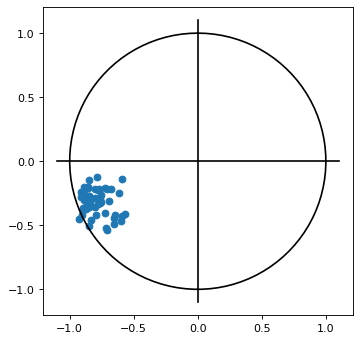

In [19]:
fig, ax = plt.subplots(figsize=(5,5), dpi = 80)


n = np.linspace(0, 2*np.pi, 100)
circ_x = np.sin(n)
circ_y = np.cos(n)

ax.plot(circ_x, circ_y,'k')
ax.plot([0,0], [-1.1, 1.1], 'k')
ax.plot([-1.1, 1.1], [0, 0], 'k')

ax.scatter(wV_spin/10, wU_spin/10)
ax.axis('equal')

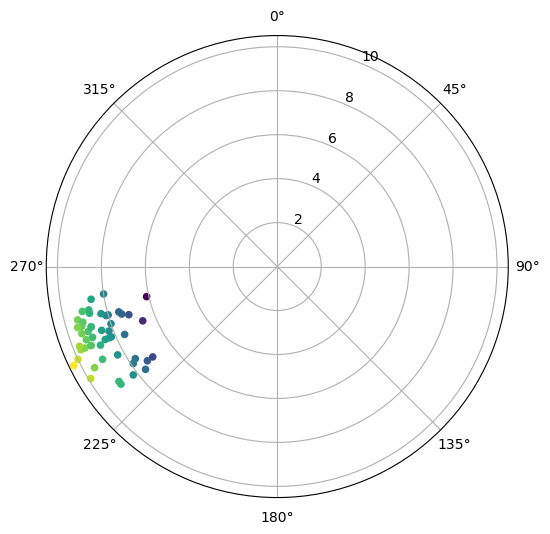

In [20]:
speed = wind_mag
theta = np.deg2rad(wind_dir + 180)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

sc = ax.scatter(theta, speed, c=speed, cmap='viridis', s=20)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)


In [ ]:
#topo

In [10]:
print(np.round(np.nanmean(data['ADCP1_UVSSC_REV'][1][:, 0]),2), np.round(np.nanmean(data['ADCP1_UVSSC_REV'][0][:, 0]),2))

-0.01 0.08


In [130]:
print(np.round(np.nanmean(data['ADCP2_UVSSC_REV'][1][:, 0]),2), np.round(np.nanmean(data['ADCP2_UVSSC_REV'][0][:, 0]),2))

0.02 0.15


In [131]:
print(np.round(np.nanmean(data['ADCP3_UVSSC_REV'][1][:, 0]),2), np.round(np.nanmean(data['ADCP3_UVSSC_REV'][0][:, 0]),2))

0.03 0.14


In [132]:
print(np.round(np.nanmean(data['ADCP4_UVSSC_REV'][1][:, 0]),2), np.round(np.nanmean(data['ADCP4_UVSSC_REV'][0][:, 0]),2))

-0.02 0.13


In [ ]:
#fundo

In [145]:
print(np.round(np.nanmean(data['ADCP1_UVSSC_REV'][1][:, -1]),2), np.round(np.nanmean(data['ADCP1_UVSSC_REV'][0][:, -1]),2))

0.01 -0.18


In [146]:
print(np.round(np.nanmean(data['ADCP2_UVSSC_REV'][1][:, -2]),3), np.round(np.nanmean(data['ADCP2_UVSSC_REV'][0][:, -2]),2))

-0.001 -0.09


In [147]:
print(np.round(np.nanmean(data['ADCP3_UVSSC_REV'][1][:, -1]),2), np.round(np.nanmean(data['ADCP3_UVSSC_REV'][0][:, -1]),2))

0.01 -0.07


In [148]:
print(np.round(np.nanmean(data['ADCP4_UVSSC_REV'][1][:, -1]),2), np.round(np.nanmean(data['ADCP4_UVSSC_REV'][0][:, -1]),2))

-0.03 -0.17


In [21]:
#
print('total / sec')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = np.sqrt(np.abs(P1_utm_E_init - P1_utm_E_traj_fundo[-1])**2 + np.abs(P1_utm_N_init - P1_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = np.sqrt(np.abs(P2_utm_E_init - P2_utm_E_traj_fundo[-1])**2 + np.abs(P2_utm_N_init - P2_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = np.sqrt(np.abs(P3_utm_E_init - P3_utm_E_traj_fundo[-1])**2 + np.abs(P3_utm_N_init - P3_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = np.sqrt(np.abs(P4_utm_E_init - P4_utm_E_traj_fundo[-1])**2 + np.abs(P4_utm_N_init - P4_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2))


total / sec
2.86
5.53
5.03
4.72


In [24]:
print('dist absol / shelf V / shelf U')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = np.sqrt((P1_utm_E_init - P1_utm_E_traj_topo[-1])**2 +(P1_utm_N_init - P1_utm_N_traj_topo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(74.23)), 2), np.round(dist_diff/1000*np.sin(np.radians(74.23)), 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = np.sqrt((P2_utm_E_init - P2_utm_E_traj_topo[-1])**2 + (P2_utm_N_init - P2_utm_N_traj_topo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(64.93)), 2), np.round(dist_diff/1000*np.sin(np.radians(64.93)), 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = np.sqrt((P3_utm_E_init - P3_utm_E_traj_topo[-1])**2 + (P3_utm_N_init - P3_utm_N_traj_topo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(47.97)), 2), np.round(dist_diff/1000*np.sin(np.radians(47.97)), 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = np.sqrt((P4_utm_E_init - P4_utm_E_traj_topo[-1])**2 + (P4_utm_N_init - P4_utm_N_traj_topo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(40.13)), 2), np.round(dist_diff/1000*np.sin(np.radians(40.13)), 2))

dist absol / shelf V / shelf U
6.32 1.72 6.08
2.94 1.25 2.67
2.3 1.54 1.71
6.12 4.68 3.94


In [25]:
print('dist absol / shelf V / shelf U')
time_diff = data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]
dist_diff = np.sqrt((P1_utm_E_init - P1_utm_E_traj_fundo[-1])**2 +(P1_utm_N_init - P1_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(74.23)), 2), np.round(dist_diff/1000*np.sin(np.radians(74.23)), 2))
#
time_diff = data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]
dist_diff = np.sqrt((P2_utm_E_init - P2_utm_E_traj_fundo[-1])**2 + (P2_utm_N_init - P2_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(64.93)), 2), np.round(dist_diff/1000*np.sin(np.radians(64.93)), 2))
#
time_diff = data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]
dist_diff = np.sqrt((P3_utm_E_init - P3_utm_E_traj_fundo[-1])**2 + (P3_utm_N_init - P3_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(47.97)), 2), np.round(dist_diff/1000*np.sin(np.radians(47.97)), 2))
#
time_diff = data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]
dist_diff = np.sqrt((P4_utm_E_init - P4_utm_E_traj_fundo[-1])**2 + (P4_utm_N_init - P4_utm_N_traj_fundo[-1])**2)
print(np.round(dist_diff/1000, 2), np.round(dist_diff/1000*np.cos(np.radians(40.13)), 2), np.round(dist_diff/1000*np.sin(np.radians(40.13)), 2))

dist absol / shelf V / shelf U
2.86 0.78 2.75
5.53 2.34 5.0
5.03 3.37 3.74
4.72 3.61 3.04


In [28]:
print(P4_utm_E_traj_topo[-1], P4_utm_N_traj_topo[-1])

389537.0664303553 6432883.467725773


In [23]:
print(f"{2.86*np.cos(np.radians(74.23)):.2f}", f"{2.86*np.sin(np.radians(74.23)):.2f}")
print(f"{5.53*np.cos(np.radians(64.93)):.2f}", f"{5.53*np.sin(np.radians(64.93)):.2f}")
print(f"{5.03*np.cos(np.radians(47.97)):.2f}", f"{5.03*np.sin(np.radians(47.97)):.2f}")
print(f"{4.71*np.cos(np.radians(40.13)):.2f}", f"{4.71*np.sin(np.radians(40.13)):.2f}")

0.78 2.75
2.34 5.01
3.37 3.74
3.60 3.04


In [23]:
print((data['ADCP1_time_REV'][-1] - data['ADCP1_time_REV'][0]).seconds,
      (data['ADCP2_time_REV'][-1] - data['ADCP2_time_REV'][0]).seconds,
      (data['ADCP3_time_REV'][-1] - data['ADCP3_time_REV'][0]).seconds,
      (data['ADCP4_time_REV'][-1] - data['ADCP4_time_REV'][0]).seconds)

35400 34800 33000 34200


In [26]:
print(np.round(np.nanmean(data['ADCP1_UVSSC_REV'][1][:, 0])*35400/1000,2), np.round(np.nanmean(data['ADCP1_UVSSC_REV'][0][:, 0])*35400/1000,2))
print(np.round(np.nanmean(data['ADCP2_UVSSC_REV'][1][:, 0])*34800/1000,2), np.round(np.nanmean(data['ADCP2_UVSSC_REV'][0][:, 0])*34800/1000,2))
print(np.round(np.nanmean(data['ADCP3_UVSSC_REV'][1][:, 0])*33000/1000,2), np.round(np.nanmean(data['ADCP3_UVSSC_REV'][0][:, 0])*33000/1000,2))
print(np.round(np.nanmean(data['ADCP4_UVSSC_REV'][1][:, 0])*34200/1000,2), np.round(np.nanmean(data['ADCP4_UVSSC_REV'][0][:, 0])*34200/1000,2))

-0.38 2.73
0.83 5.28
1.03 4.77
-0.63 4.53


In [27]:
print(np.round(np.nanmean(data['ADCP1_UVSSC_REV'][1][:, -1])*35400/1000,2), np.round(np.nanmean(data['ADCP1_UVSSC_REV'][0][:, -1])*35400/1000,2))
print(np.round(np.nanmean(data['ADCP2_UVSSC_REV'][1][:, -1])*34800/1000,2), np.round(np.nanmean(data['ADCP2_UVSSC_REV'][0][:, -1])*34800/1000,2))
print(np.round(np.nanmean(data['ADCP3_UVSSC_REV'][1][:, -1])*33000/1000,2), np.round(np.nanmean(data['ADCP3_UVSSC_REV'][0][:, -1])*33000/1000,2))
print(np.round(np.nanmean(data['ADCP4_UVSSC_REV'][1][:, -1])*34200/1000,2), np.round(np.nanmean(data['ADCP4_UVSSC_REV'][0][:, -1])*34200/1000,2))

0.3 -6.27
-0.48 -5.24
0.4 -2.29
-1.18 -5.78
